# $wCDM$ VS $CPL$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import cumulative_trapezoid
from dynesty import (
    NestedSampler,
    plotting as dyplot
)

## **Data**

In [2]:
data = np.loadtxt("data_2.txt")
data.shape

(150, 3)

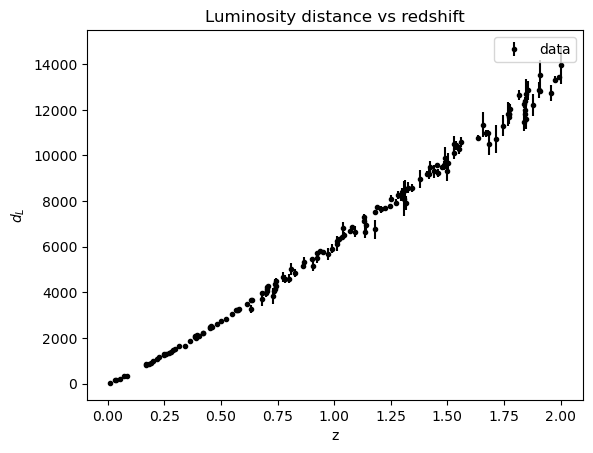

In [3]:
z_data = data[:, 0]
dL_obs = data[:, 1]
dL_err = data[:, 2]

H0 = 72 # 72 km/s/Mpc
c = 299792.458

z_grid = np.linspace(0, 2, 500)

plt.errorbar(z_data, dL_obs, yerr=dL_err, fmt=".k", capsize=0, label="data")
plt.title("Luminosity distance vs redshift")
plt.xlabel("z")
plt.ylabel(r"$d_L$")
plt.legend()
plt.show()

## **wCDM model**

In [4]:
def H_wCDM(z, params):
    Om_0, w0 = params
    fz = (1+z)**(3*(1+w0))
    expr = Om_0*(1+z)**3 + (1-Om_0)*fz
    return H0 * np.sqrt(expr)

def dL_wCDM(z, params):
    Hz = H_wCDM(z_grid, params)
    integrand = 1 / Hz
    I = cumulative_trapezoid(integrand, z_grid, initial=0)
    dL_grid = (1+z_grid) * c * I
    return np.interp(z, z_grid, dL_grid)

def log_like_wCDM(params):
    dL_th = dL_wCDM(z_data, params)
    #norm = -0.5 * np.sum(np.log(2 * np.pi * dL_err**2))
    return -0.5 * np.sum(((dL_obs - dL_th) / dL_err)**2)

def prior_wCDM(u):
    om = 0.2 + 0.4 * u[0]     # Ωm ∈ [0.2, 0.6]
    w  = -3 + 3 * u[1]   # w ∈ [-3.0, 0]
    return np.array([om, w])

## initialize nested sampling
ndim1 = 2

sampler_wCDM = NestedSampler(
    log_like_wCDM,
    prior_wCDM,
    ndim1,
    nlive=1000
)
sampler_wCDM.run_nested()

results_wCDM = sampler_wCDM.results
results_wCDM.summary()


11634it [00:38, 302.64it/s, +1000 | bound: 15 | nc: 1 | ncall: 50950 | eff(%): 25.293 | loglstar:   -inf < -375.154 <    inf | logz: -386.537 +/-  0.102 | dlogz:  0.001 >  1.009]

Summary
nlive: 1000
niter: 11634
ncall: 49950
eff(%): 25.293
logz: -386.537 +/-  0.245


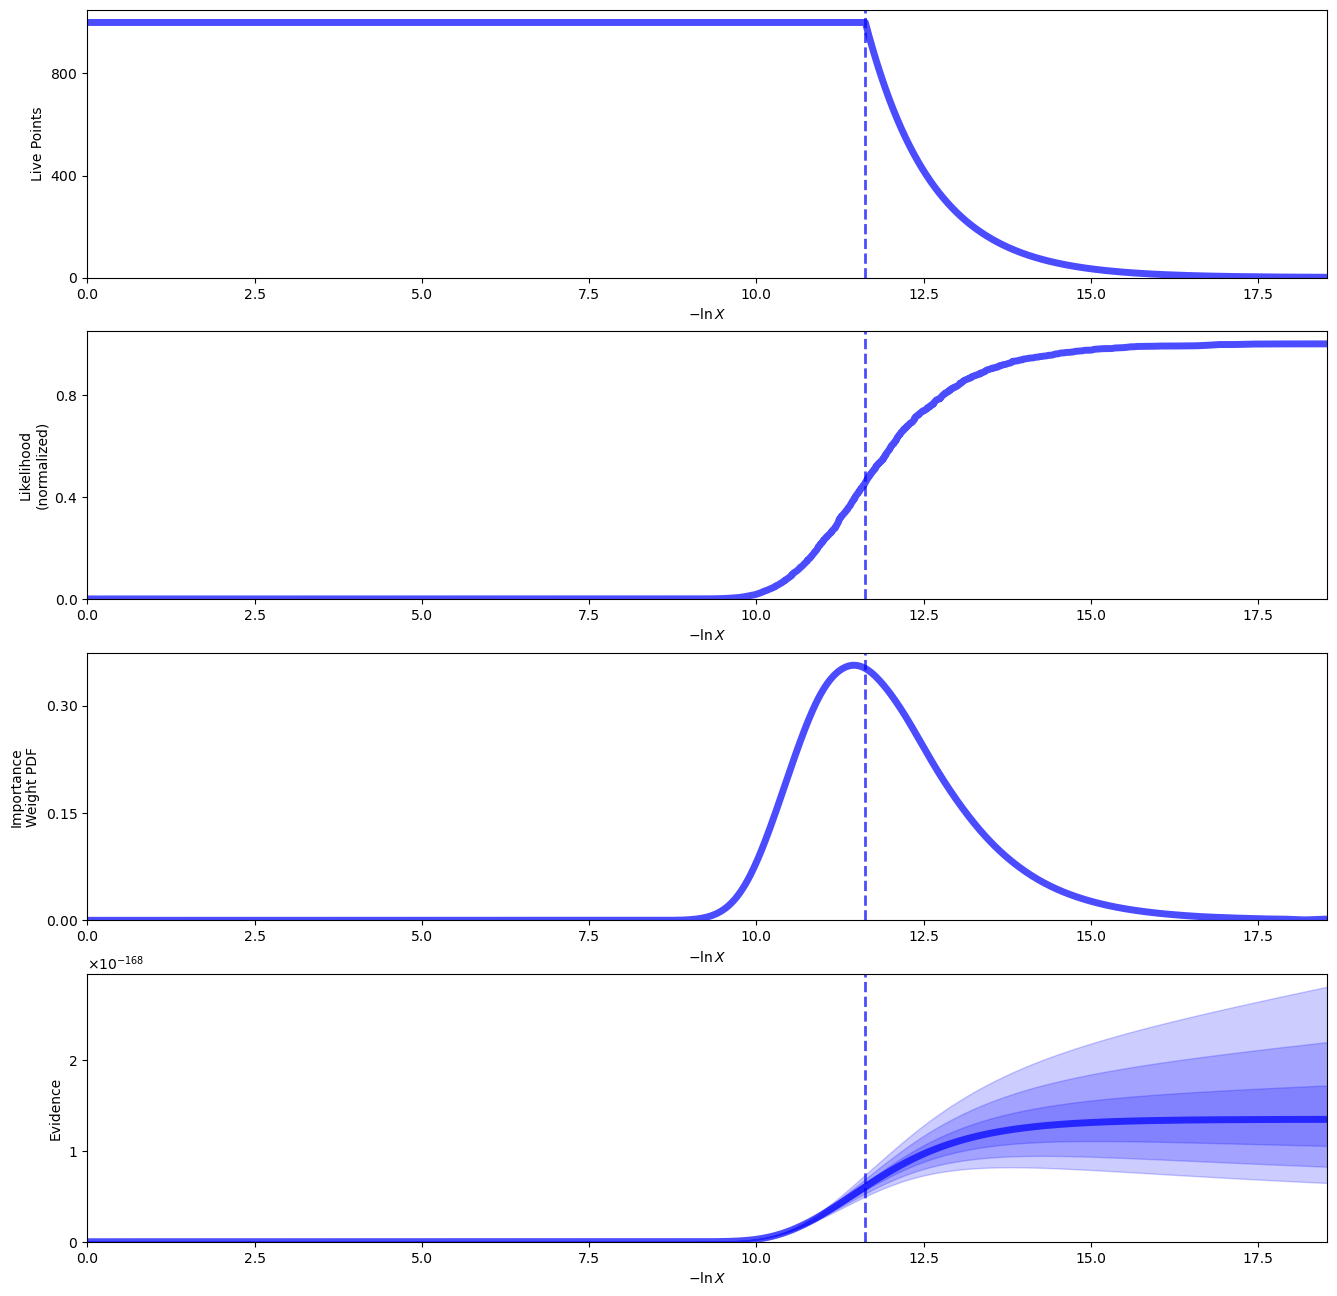

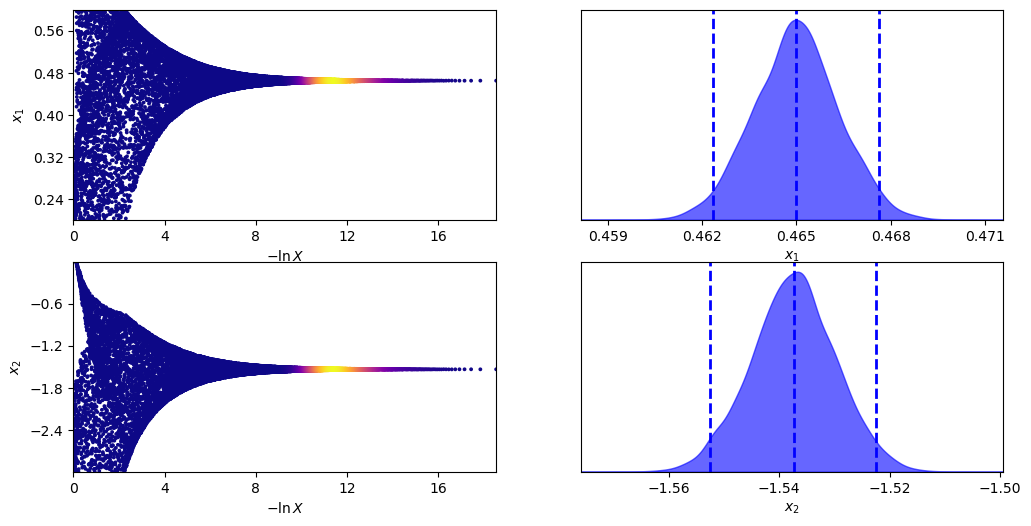

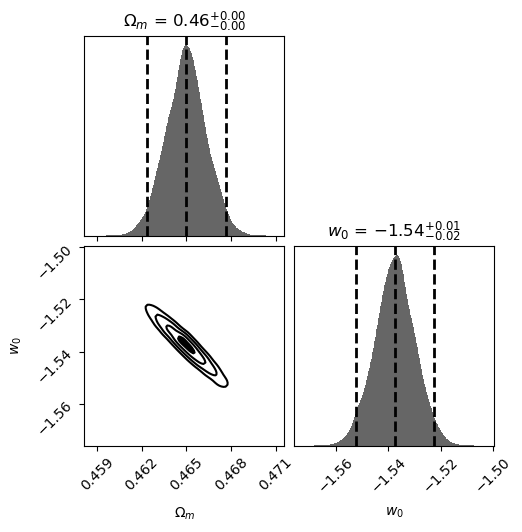

In [5]:
rfig, raxes = dyplot.runplot(results_wCDM)

tfig, taxes = dyplot.traceplot(results_wCDM)

cfig, caxes =dyplot.cornerplot(
    results_wCDM,
    labels = [r"$\Omega_m$", r"$w_0$"],
    truths=np.zeros(ndim1),
    truth_color='black',
    show_titles=True
)


## **CPL model**

In [6]:
def H_CPL(z, params):
    Om_0, w0, wa = params
    fz = (1 + z)**(3*(1 + w0 + wa)) * np.exp(-3*wa*(z/(1 + z)))
    expr = Om_0*(1+z)**3 + (1-Om_0)*fz
    return H0 * np.sqrt(expr)

def dL_CPL(z, params):
    Hz = H_CPL(z_grid, params)
    integrand = 1 / Hz
    I = cumulative_trapezoid(integrand, z_grid, initial=0)
    dL_grid = (1+z_grid) * c * I
    return np.interp(z, z_grid, dL_grid)

def log_like_CPL(params):
    dL_th = dL_CPL(z_data, params)
    return -0.5 * np.sum(((dL_obs - dL_th) / dL_err)**2)

def prior_CPL(u):
    om = 0.2 + 0.4 * u[0]    
    w0  = -3 + 3 * u[1] 
    wa = -10 + 10 * u[2]  
    return np.array([om, w0, wa])

## initialize nested sampling
ndim2 = 3

sampler_CPL = NestedSampler(
    log_like_CPL,
    prior_CPL,
    ndim2,
    nlive=1000
)
sampler_CPL.run_nested()

results_CPL = sampler_CPL.results
results_CPL.summary()

13791it [00:52, 263.30it/s, +1000 | bound: 28 | nc: 1 | ncall: 63498 | eff(%): 23.666 | loglstar:   -inf < -136.259 <    inf | logz: -149.946 +/-  0.120 | dlogz:  0.001 >  1.009]

Summary
nlive: 1000
niter: 13791
ncall: 62498
eff(%): 23.666
logz: -149.946 +/-  0.275


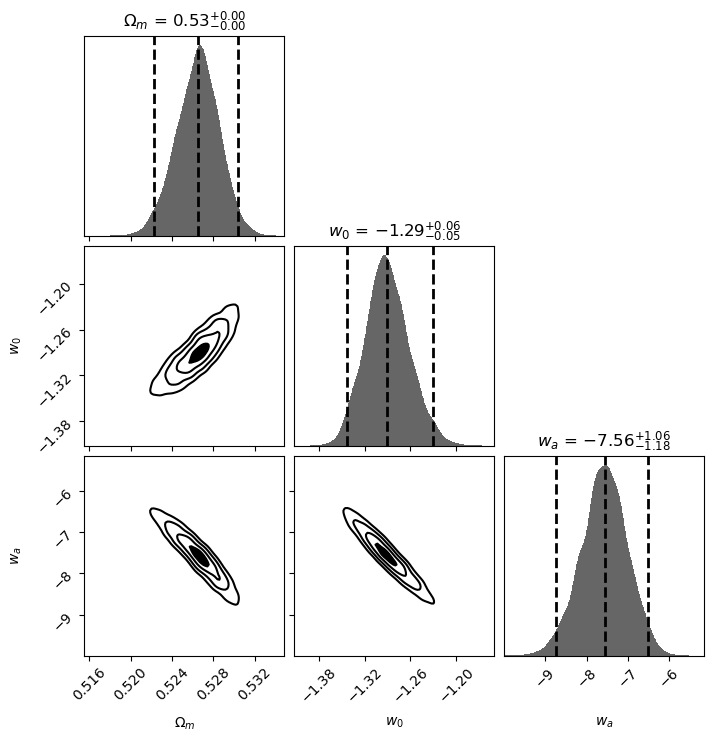

In [7]:
cfig, caxes = dyplot.cornerplot(
    results_CPL,
    truths=np.zeros(ndim2),
    labels = [r"$\Omega_m$", r"$w_0$", r"$w_a$"],
    truth_color='black',
    show_titles=True
)

## **Model comparison**

In [8]:
logz_wCDM     = results_wCDM.logz[-1]
logzerr_wCDM  = results_wCDM.logzerr[-1]

logz_CPL      = results_CPL.logz[-1]
logzerr_CPL   = results_CPL.logzerr[-1]

logBF = logz_wCDM - logz_CPL
logBF_err = np.sqrt(logzerr_wCDM**2 + logzerr_CPL**2)

logBF, logBF_err


(-236.5911706301489, 0.36801719212177114)

$\Delta \log Z \ll -5$

According to the Jeffreys scale, **decisive evidence in favor of the CPL model**

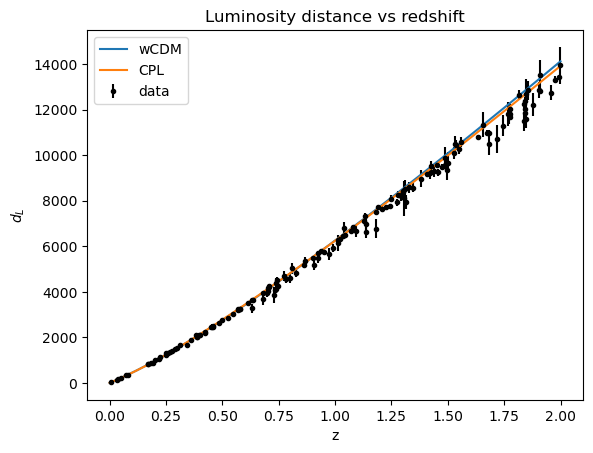

In [9]:
samples_wCDM = results_wCDM.samples
samples_CPL = results_CPL.samples

Om_0_wCDM, w0_wCDM = samples_wCDM[:, 0].mean(), samples_wCDM[:, 1].mean()
Om_0_CPL, w0_CPL, wa_CPL = samples_CPL[:, 0].mean(), samples_CPL[:, 1].mean(), samples_CPL[:, 2].mean()

dL_th_wCDM = dL_wCDM(z_grid, np.array([Om_0_wCDM, w0_wCDM]))
dL_th_CPL = dL_CPL(z_grid, np.array([Om_0_CPL, w0_CPL, wa_CPL]))

plt.errorbar(z_data, dL_obs, yerr=dL_err, fmt=".k", capsize=0, label="data")
plt.plot(z_grid, dL_th_wCDM, label="wCDM")
plt.plot(z_grid, dL_th_CPL, label="CPL")
plt.title("Luminosity distance vs redshift")
plt.xlabel("z")
plt.ylabel(r"$d_L$")
plt.legend()
plt.show()